# Memory consumption of NRI
The NRI decoder calculates Edge Features for every edge of the fully connected graph. The related tensor has shape:
`[B, T/pred_steps, N * (N-1), X_dim]`. Let's assume the values below and see how the memory consumption grows depending on the number of nodes `N`:
$$Mem_{B, T, X\_dim, pred\_steps}(N) = (B * T * N * (N - 1) * X\_dim * bytes\_per\_float) / (pred\_steps * 1e6)$$


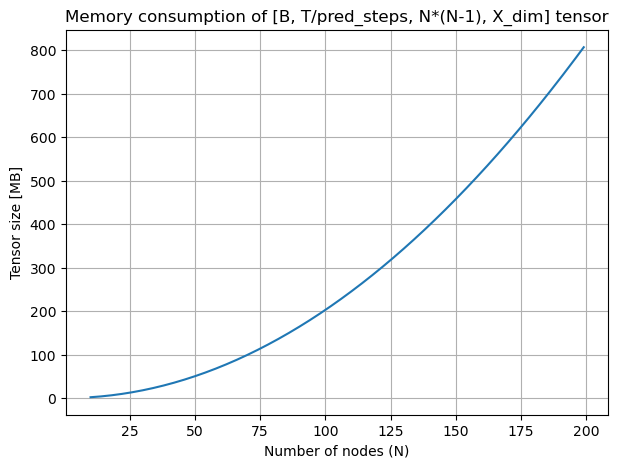

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# fixed parameters
B = 8
T = 100
pred_steps = 5
X_dim = 32
bytes_per_float = 4  # float32

# range of N
N = np.arange(10, 200)

# compute size in megabytes
S_MB = (B * T * N * (N - 1) * X_dim * bytes_per_float) / (pred_steps * 1e6)

# plot
plt.figure(figsize=(7, 5))
plt.plot(N, S_MB)
plt.xlabel("Number of nodes (N)")
plt.ylabel("Tensor size [MB]")
plt.title("Memory consumption of [B, T/pred_steps, N*(N-1), X_dim] tensor")
plt.grid(True)
plt.show()